# Single Prompt Optimization

This notebook is the reduced single-prompt workflow for SDXL Turbo with LAION Aesthetic Score V2 and CLIP Score.
Choose either `cmaes` for sep-CMA-ES or `adam` for Adam.


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
if repo_root.name == 'notebook':
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.utils import make_config, run_single_prompt_experiment


In [5]:
single_prompt_config = make_config(
    # General settings
    selected_prompt= "an astronaut riding a horse on Mars",
    optimization_method= "cmaes", # Optimization method: 'cmaes' for sep-CMA-ES or 'adam' for Adam.
    seed= 42, # Random seed for reproducibility across prompt embedding optimization runs.
    cuda= 0, # CUDA device index used for all computations. Set "cpu" to run on CPU.
    num_inference_steps= 1, # Number of denoising steps used by SDXL Turbo during image generation.
    guidance_scale= 0.0, # Classifier-free guidance scale; 0.0 keeps the setup in the intended turbo regime.
    height= 512, # Image height in pixels for generated images.
    width= 512, # Image width in pixels for generated images.
    aesthetic_score_weight= 0.5, # Weight for the aesthetic score in the combined reward function.
    clip_score_weight= 0.5, # Weight for the CLIP score in the combined reward function.
    max_aesthetic_score= 10.0, # Maximum possible aesthetic score from the predictor, used for rescaling.
    max_clip_score= 0.5, # Maximum possible CLIP score from the predictor, used for rescaling.
    model_id= "stabilityai/sdxl-turbo", # Hugging Face model identifier for the diffusion backbone.
    results_folder=str(repo_root / 'results' / 'batch_comparison'), # Folder where results of the batch experiment will be saved.
    # sep-CMA-ES specific parameters:
    num_generations=20,
    pop_size= 20,
    sigma= 0.5,
    save_gens= False, # Whether to save generated images for each generation.
    # Adam specific parameters:
    num_iterations= 400,
    adam_lr= 1e-4,
    adam_weight_decay= 0.0,
    adam_eps= 1e-8,
    adam_beta1= 0.9,
    adam_beta2= 0.999,
    # Time limit for the optimization process in seconds.
    time_limit_seconds=None, # Set to None to follow the number of generations/iterations.
)


In [6]:
results_folder = run_single_prompt_experiment(single_prompt_config)
results_folder


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

/home/posgrad/phd2025/dneto/ope_experiments/src/utils.py:188: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(weights_path, map_location=self.device)


Generation 1/20
Generation 1/20: Max fitness=0.6393, Max aesthetic=6.2113, Max clip=0.3321, ETA=1m 53s
Generation 2/20
Generation 2/20: Max fitness=0.6571, Max aesthetic=6.3960, Max clip=0.3373, ETA=1m 51s
Generation 3/20
Generation 3/20: Max fitness=0.6368, Max aesthetic=6.3276, Max clip=0.3261, ETA=1m 47s
Generation 4/20
Generation 4/20: Max fitness=0.6496, Max aesthetic=6.5561, Max clip=0.3260, ETA=1m 41s
Generation 5/20
Generation 5/20: Max fitness=0.6629, Max aesthetic=6.7144, Max clip=0.3290, ETA=1m 35s
Generation 6/20
Generation 6/20: Max fitness=0.6623, Max aesthetic=6.7656, Max clip=0.3313, ETA=1m 29s
Generation 7/20
Generation 7/20: Max fitness=0.6663, Max aesthetic=6.8376, Max clip=0.3315, ETA=1m 22s
Generation 8/20
Generation 8/20: Max fitness=0.6577, Max aesthetic=6.9689, Max clip=0.3301, ETA=1m 16s
Generation 9/20
Generation 9/20: Max fitness=0.6717, Max aesthetic=6.9658, Max clip=0.3288, ETA=1m 10s
Generation 10/20
Generation 10/20: Max fitness=0.6774, Max aesthetic=6.99

'/home/posgrad/phd2025/dneto/ope_experiments/results/batch_comparison/sepcmaes_laionv2_sdxl_sdxlturbo_seed42'

### Initial Image (no optimization)

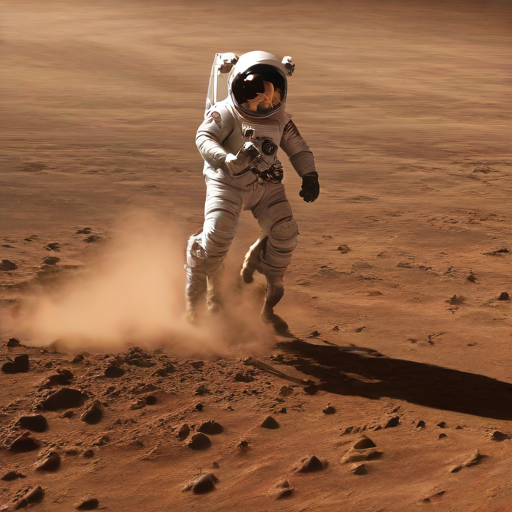

### Final output

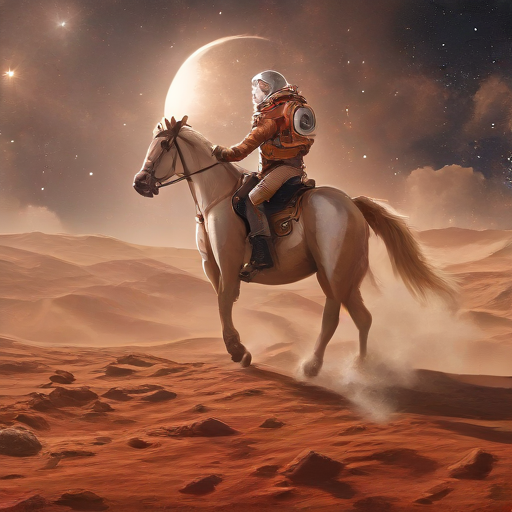

### Aesthetic Score Evolution

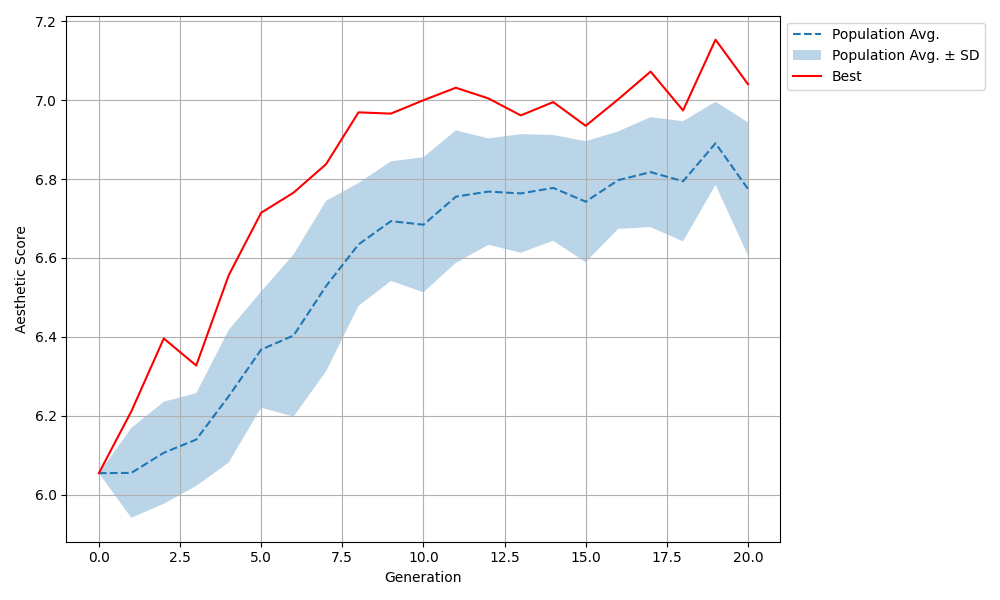

### CLIP Score Evolution

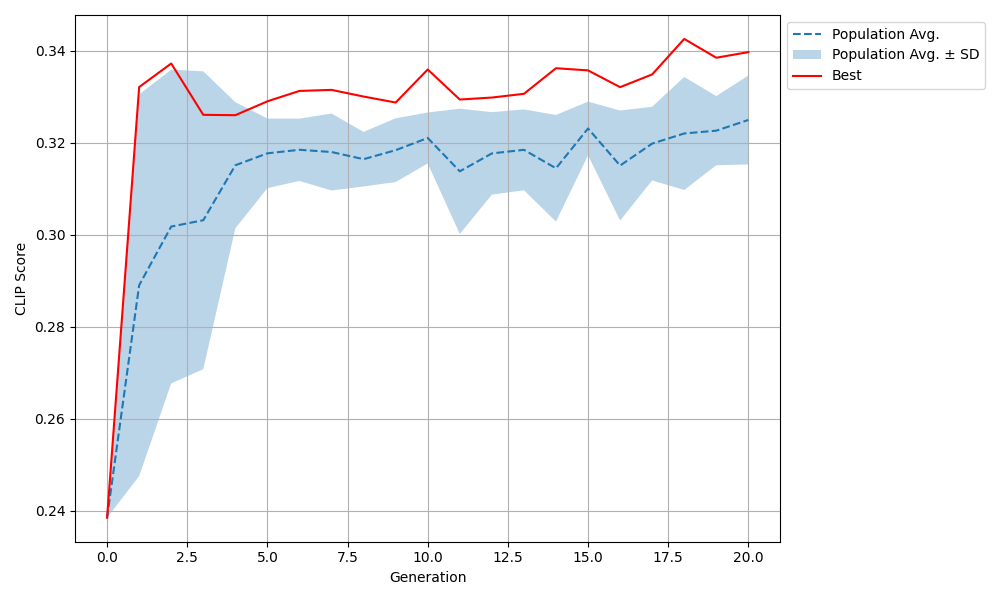

### Fitness Evolution

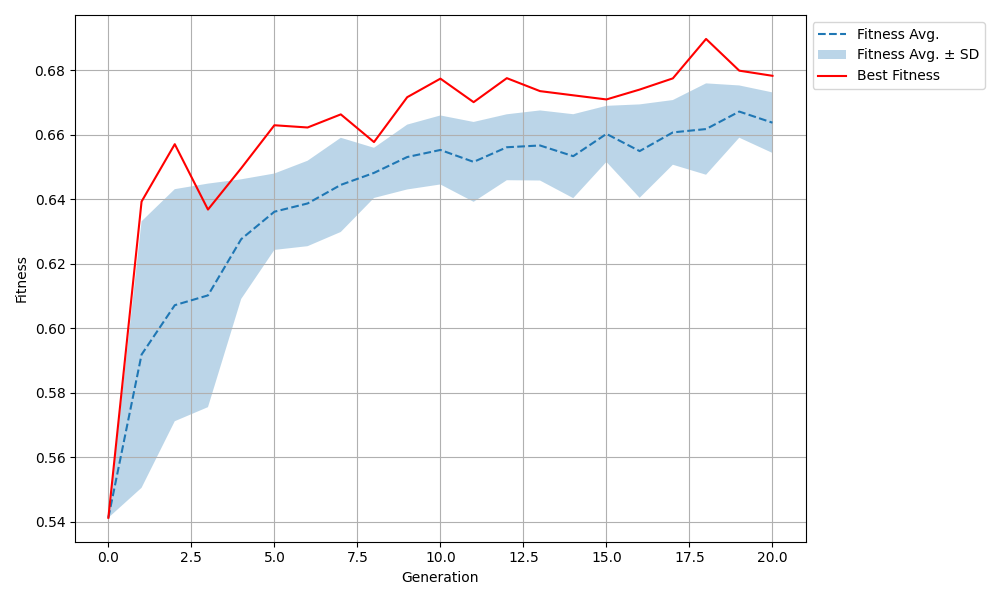

In [7]:
from IPython.display import Image, Markdown, display

results_path = Path(results_folder)
display(Markdown('### Initial Image (no optimization)'))
display(Image(filename=str(results_path / 'it_0.png')))
display(Markdown('### Final output'))
display(Image(filename=str(results_path / 'best_all.png')))

if single_prompt_config['optimization_method'] == 'cmaes':
    display(Markdown('### Aesthetic Score Evolution'))
    display(Image(filename=str(results_path / 'aesthetic_score_evolution.png')))
    display(Markdown('### CLIP Score Evolution'))
    display(Image(filename=str(results_path / 'clip_score_evolution.png')))
    display(Markdown('### Fitness Evolution'))
    display(Image(filename=str(results_path / 'fitness_evolution.png')))
else:
    display(Markdown('### Aesthetic Score Evolution'))
    display(Image(filename=str(results_path / 'aesthetic_evolution.png')))
    display(Markdown('### CLIP Score Evolution'))
    display(Image(filename=str(results_path / 'clip_evolution.png')))
    display(Markdown('### Loss Evolution'))
    display(Image(filename=str(results_path / 'loss_evolution.png')))
